# GARCH(1,1) Volatility Forecast — PBR / MOM Z-Score STD

## 목적
> 이전 1년(252 거래일) 동안의 **PBR Z-Score STD**, **MOM Z-Score STD**로 GARCH(1,1)를 학습하고,
> 이후 1개월(21 거래일) 동안 **1d / 5d / 21d** 앞의 변동성을 예측한다.

## 설계
- **대상 시리즈**: 섹터 간 1Y Rolling Z-Score의 횡단면 표준편차 (raw daily, 스무딩 없음)
- **Train**: 이전 252 거래일 — 파라미터 학습
- **Test**: 이후 21 거래일 — 파라미터 고정 후 예측
- **Slide**: 21일 후 재학습
- **Horizon**: 1d / 5d / 21d (같은 GARCH 모델에서 `forecast(horizon=21)` 한 번 호출로 추출)

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "arch", "statsmodels", "scikit-learn", "-q"], check=True)
print("설치 완료")

설치 완료



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR   = Path(".")
PBR_PATH   = BASE_DIR / "krx_sector_pbr.csv"
PRICE_PATH = BASE_DIR / "kodex_sector_etf_close.csv"
BENCHMARK_LABEL = "섹터평균"
SECTOR_ALIAS_MAP = {"IT": "정보기술", "K콘텐츠": "K콘텐츠"}
print("임포트 완료")

임포트 완료


In [3]:
# ── 데이터 로드 & 시리즈 생성 ──────────────────────────────────────────────

def normalize_sector_name(name: str) -> str:
    s = str(name).strip()
    s = re.sub(r"^KODEX\s+", "", s)
    s = re.sub(r"^KRX\s+", "", s)
    s = re.sub(r"\s+", "", s)
    return SECTOR_ALIAS_MAP.get(s, s)

def rolling_zscore(data: pd.DataFrame, window: int) -> pd.DataFrame:
    mean = data.rolling(window=window, min_periods=1).mean()
    std  = data.rolling(window=window, min_periods=1).std()
    return (data - mean) / (std + 1e-10)

# 로드
pbr_df   = pd.read_csv(PBR_PATH,   parse_dates=["날짜"])
price_df = pd.read_csv(PRICE_PATH, parse_dates=["날짜"])

# 전처리
pbr_daily = (pbr_df.rename(columns={"날짜":"date"})
             .sort_values("date").set_index("date")
             .rename(columns=normalize_sector_name))
price_daily = (price_df.rename(columns={"날짜":"date"})
               .sort_values("date").set_index("date")
               .rename(columns=normalize_sector_name))

common_sectors = sorted(set(pbr_daily.columns) & set(price_daily.columns))
common_dates   = pbr_daily.index.intersection(price_daily.index)
pbr_daily   = pbr_daily.loc[common_dates, common_sectors]
price_daily = price_daily.loc[common_dates, common_sectors]

WINDOW  = 252
sectors = [c for c in common_sectors if c != BENCHMARK_LABEL]

# 1Y Rolling Z-Score
pbr_z  = rolling_zscore(pbr_daily, WINDOW)
mom_z  = rolling_zscore(price_daily.pct_change(WINDOW) * 100, WINDOW)

# Cross-sectional STD (raw daily, 스무딩 없음)
pbr_std = pbr_z[sectors].std(axis=1).rename("pbr_std")
mom_std = mom_z[sectors].std(axis=1).rename("mom_std")

# 안정화 기간(WINDOW*2) 제거
pbr_std = pbr_std.iloc[WINDOW * 2:].dropna()
mom_std = mom_std.iloc[WINDOW * 2:].dropna()

print(f"공통 섹터 수  : {len(sectors)}")
print(f"PBR Std 기간  : {pbr_std.index.min().date()} ~ {pbr_std.index.max().date()}  n={len(pbr_std)}")
print(f"MOM Std 기간  : {mom_std.index.min().date()} ~ {mom_std.index.max().date()}  n={len(mom_std)}")
print()
print(pbr_std.describe().rename("PBR Std").to_frame().join(mom_std.describe().rename("MOM Std")))

공통 섹터 수  : 15
PBR Std 기간  : 2012-01-09 ~ 2026-03-30  n=3491
MOM Std 기간  : 2012-01-09 ~ 2026-03-30  n=3491



           PBR Std      MOM Std
count  3491.000000  3491.000000
mean      1.150305     1.003920
std       0.322302     0.343021
min       0.428817     0.181698
25%       0.940890     0.769380
50%       1.134799     0.998533
75%       1.345462     1.240445
max       2.792139     1.972144


In [4]:
# ── ADF 정상성 간이 확인 ────────────────────────────────────────────────────
for series, name in [(pbr_std, "PBR Std"), (mom_std, "MOM Std")]:
    r = adfuller(series.dropna(), autolag="AIC")
    tag = "정상 ✓" if r[1] < 0.05 else "비정상 ✗"
    print(f"[{name}]  ADF={r[0]:.3f}  p={r[1]:.4f}  → {tag}")

[PBR Std]  ADF=-6.607  p=0.0000  → 정상 ✓


[MOM Std]  ADF=-4.536  p=0.0002  → 정상 ✓


## Walk-Forward 설계

```
Train : 이전 252 거래일 (1Y)  ← GARCH(1,1) 학습
Test  : 이후  21 거래일 (1M)  ← 파라미터 고정, 예측 평가
Slide : 21일씩 이동 후 재학습

Forecast horizon (같은 모델에서 추출):
  1d  — 내일의 STD
  5d  — 5 거래일 후 STD
  21d — 21 거래일 후 STD

forecast(horizon=21) 한 번 호출 → h=1,5,21 세 지점 동시 추출
pred_means[k + h - 1] = t+k 시점에서 h-step-ahead 예측
```

In [5]:
# ── Walk-Forward GARCH 예측 함수 ────────────────────────────────────────────

TRAIN    = 252
TEST     = 21
HORIZONS = [1, 5, 21]

def walk_forward_garch(series: pd.Series, name: str) -> dict:
    """
    Returns: dict[horizon] -> DataFrame(pred_mean, pred_vol, actual)
    """
    s = series.dropna() * 100   # GARCH 수렴 안정화
    n = len(s)
    buf = {h: {"pred_mean": [], "pred_vol": [], "actual": [], "date": []}
           for h in HORIZONS}

    n_windows = 0
    t = TRAIN
    while t < n:
        train = s.iloc[t - TRAIN: t]

        # GARCH(1,1) 학습
        m   = arch_model(train, mean="ARX", lags=1, vol="GARCH", p=1, q=1, dist="normal")
        res = m.fit(disp="off", show_warning=False)

        # horizon=21 한 번 호출 → 모든 h 추출
        fc         = res.forecast(horizon=max(HORIZONS), reindex=False)
        pred_means = fc.mean.iloc[-1].values       # (21,)
        pred_vars  = fc.variance.iloc[-1].values   # (21,)

        # 테스트 21일 동안 각 날짜 × horizon 저장
        for k in range(TEST):
            if t + k >= n:
                break
            for h in HORIZONS:
                step = k + h - 1          # forecast array index (0-based)
                tgt  = t + k + (h - 1)   # 실제값 인덱스
                if step >= max(HORIZONS) or tgt >= n:
                    continue
                buf[h]["pred_mean"].append(pred_means[step] / 100)
                buf[h]["pred_vol"].append(np.sqrt(pred_vars[step]) / 100)
                buf[h]["actual"].append(s.iloc[tgt] / 100)
                buf[h]["date"].append(s.index[t + k])

        n_windows += 1
        t += TEST

        if n_windows % 10 == 0:
            print(f"  [{name}] 재학습 {n_windows}회 완료 ({t}/{n})", end="\r")

    print(f"  [{name}] 총 {n_windows}회 재학습 완료.    ")

    return {
        h: pd.DataFrame(buf[h]).set_index(pd.DatetimeIndex(buf[h]["date"])).drop(columns="date")
        for h in HORIZONS
    }

In [6]:
# ── 예측 실행 ────────────────────────────────────────────────────────────────
print("PBR Std Walk-Forward 예측 중...")
res_pbr = walk_forward_garch(pbr_std, "PBR")

print("\nMOM Std Walk-Forward 예측 중...")
res_mom = walk_forward_garch(mom_std, "MOM")

PBR Std Walk-Forward 예측 중...


  [PBR] 총 155회 재학습 완료.    

MOM Std Walk-Forward 예측 중...


  [MOM] 총 155회 재학습 완료.    


In [7]:
# ── 수치 정확도 평가 ─────────────────────────────────────────────────────────

def eval_horizon(df: pd.DataFrame, series_name: str, h: int) -> dict:
    v    = df.dropna()
    rmse = np.sqrt(mean_squared_error(v["actual"], v["pred_mean"]))
    mae  = mean_absolute_error(v["actual"], v["pred_mean"])
    mape = (np.abs(v["actual"] - v["pred_mean"]) / v["actual"].abs().replace(0, np.nan)).mean()
    corr = v["pred_mean"].corr(v["actual"])
    # 방향 정확도 (보조)
    da   = np.mean(np.sign(v["actual"].diff().dropna()) == np.sign(v["pred_mean"].diff().dropna()))
    mean_act = v["actual"].mean()
    return dict(series=series_name, h=h, n=len(v),
                rmse=rmse, rmse_pct=rmse/mean_act*100,
                mae=mae,  mae_pct=mae/mean_act*100,
                mape=mape, corr=corr, dir_acc=da)

rows = []
for name, res in [("PBR", res_pbr), ("MOM", res_mom)]:
    for h in HORIZONS:
        rows.append(eval_horizon(res[h], name, h))

report = pd.DataFrame(rows).set_index(["series", "h"])
report_disp = report[["n", "rmse", "rmse_pct", "mae", "mae_pct", "mape", "corr", "dir_acc"]].copy()
report_disp.columns = ["n", "RMSE", "RMSE%mean", "MAE", "MAE%mean", "MAPE", "Corr", "DirAcc"]
report_disp["RMSE%mean"] = report_disp["RMSE%mean"].map("{:.1f}%".format)
report_disp["MAE%mean"]  = report_disp["MAE%mean"].map("{:.1f}%".format)
report_disp["MAPE"]      = report_disp["MAPE"].map("{:.1%}".format)
report_disp["Corr"]      = report_disp["Corr"].map("{:.4f}".format)
report_disp["DirAcc"]    = report_disp["DirAcc"].map("{:.1%}".format)
report_disp["RMSE"]      = report_disp["RMSE"].map("{:.4f}".format)
report_disp["MAE"]       = report_disp["MAE"].map("{:.4f}".format)

print(report_disp.to_string())

              n    RMSE RMSE%mean     MAE MAE%mean   MAPE    Corr DirAcc
series h                                                                
PBR    1   3239  0.2338     20.2%  0.1625    14.1%  14.7%  0.7040  53.4%
       5   2619  0.2498     21.6%  0.1805    15.6%  16.4%  0.6552  53.4%
       21   154  0.2899     25.1%  0.2277    19.7%  20.8%  0.5033  40.5%
MOM    1   3239  0.1769     17.3%  0.1329    13.0%  14.1%  0.8560  50.9%
       5   2619  0.1911     18.7%  0.1479    14.5%  15.8%  0.8306  50.5%
       21   154  0.2378     23.3%  0.1899    18.6%  21.0%  0.7298  45.8%


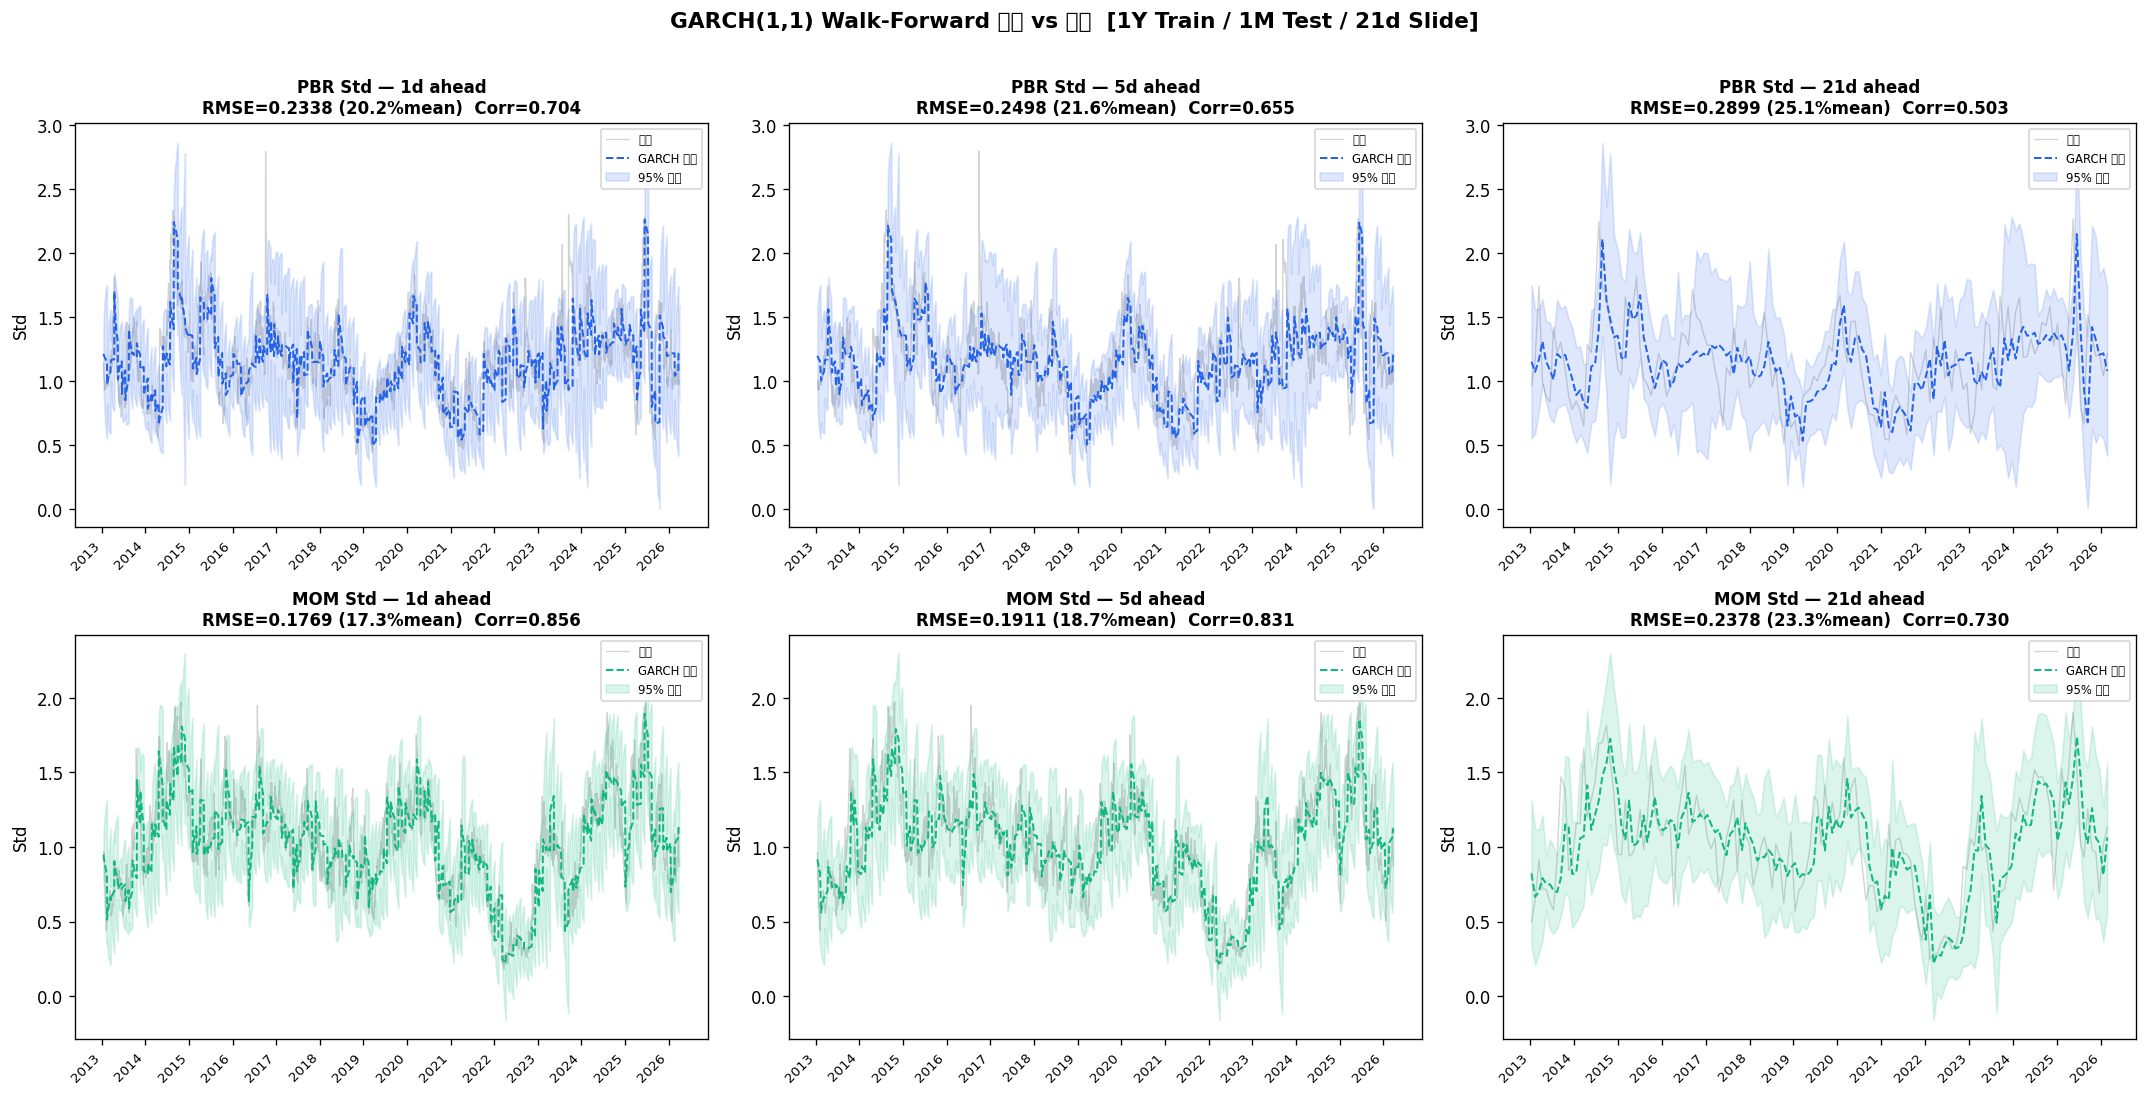

In [8]:
# ── 시계열 시각화: 예측 vs 실제 ─────────────────────────────────────────────
colors = {"PBR": "#2563eb", "MOM": "#10b981"}
h_labels = {1: "1d ahead", 5: "5d ahead", 21: "21d ahead"}

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for row, (name, res) in enumerate([("PBR", res_pbr), ("MOM", res_mom)]):
    for col, h in enumerate(HORIZONS):
        ax  = axes[row][col]
        df  = res[h].dropna()
        c   = colors[name]
        r   = eval_horizon(res[h], name, h)

        ax.plot(df.index, df["actual"].values,    lw=0.8, color="lightgray", label="실제", zorder=1)
        ax.plot(df.index, df["pred_mean"].values, lw=1.2, color=c, linestyle="--", label="GARCH 예측", zorder=2)
        ax.fill_between(df.index,
                        df["pred_mean"] - 1.96 * df["pred_vol"],
                        df["pred_mean"] + 1.96 * df["pred_vol"],
                        alpha=0.15, color=c, label="95% 구간")

        ax.set_title(f"{name} Std — {h_labels[h]}\nRMSE={r['rmse']:.4f} ({r['rmse_pct']:.1f}%mean)  Corr={r['corr']:.3f}",
                     fontsize=10, fontweight="bold")
        ax.set_ylabel("Std")
        ax.legend(fontsize=7, loc="upper right")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.suptitle("GARCH(1,1) Walk-Forward 예측 vs 실제  [1Y Train / 1M Test / 21d Slide]",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

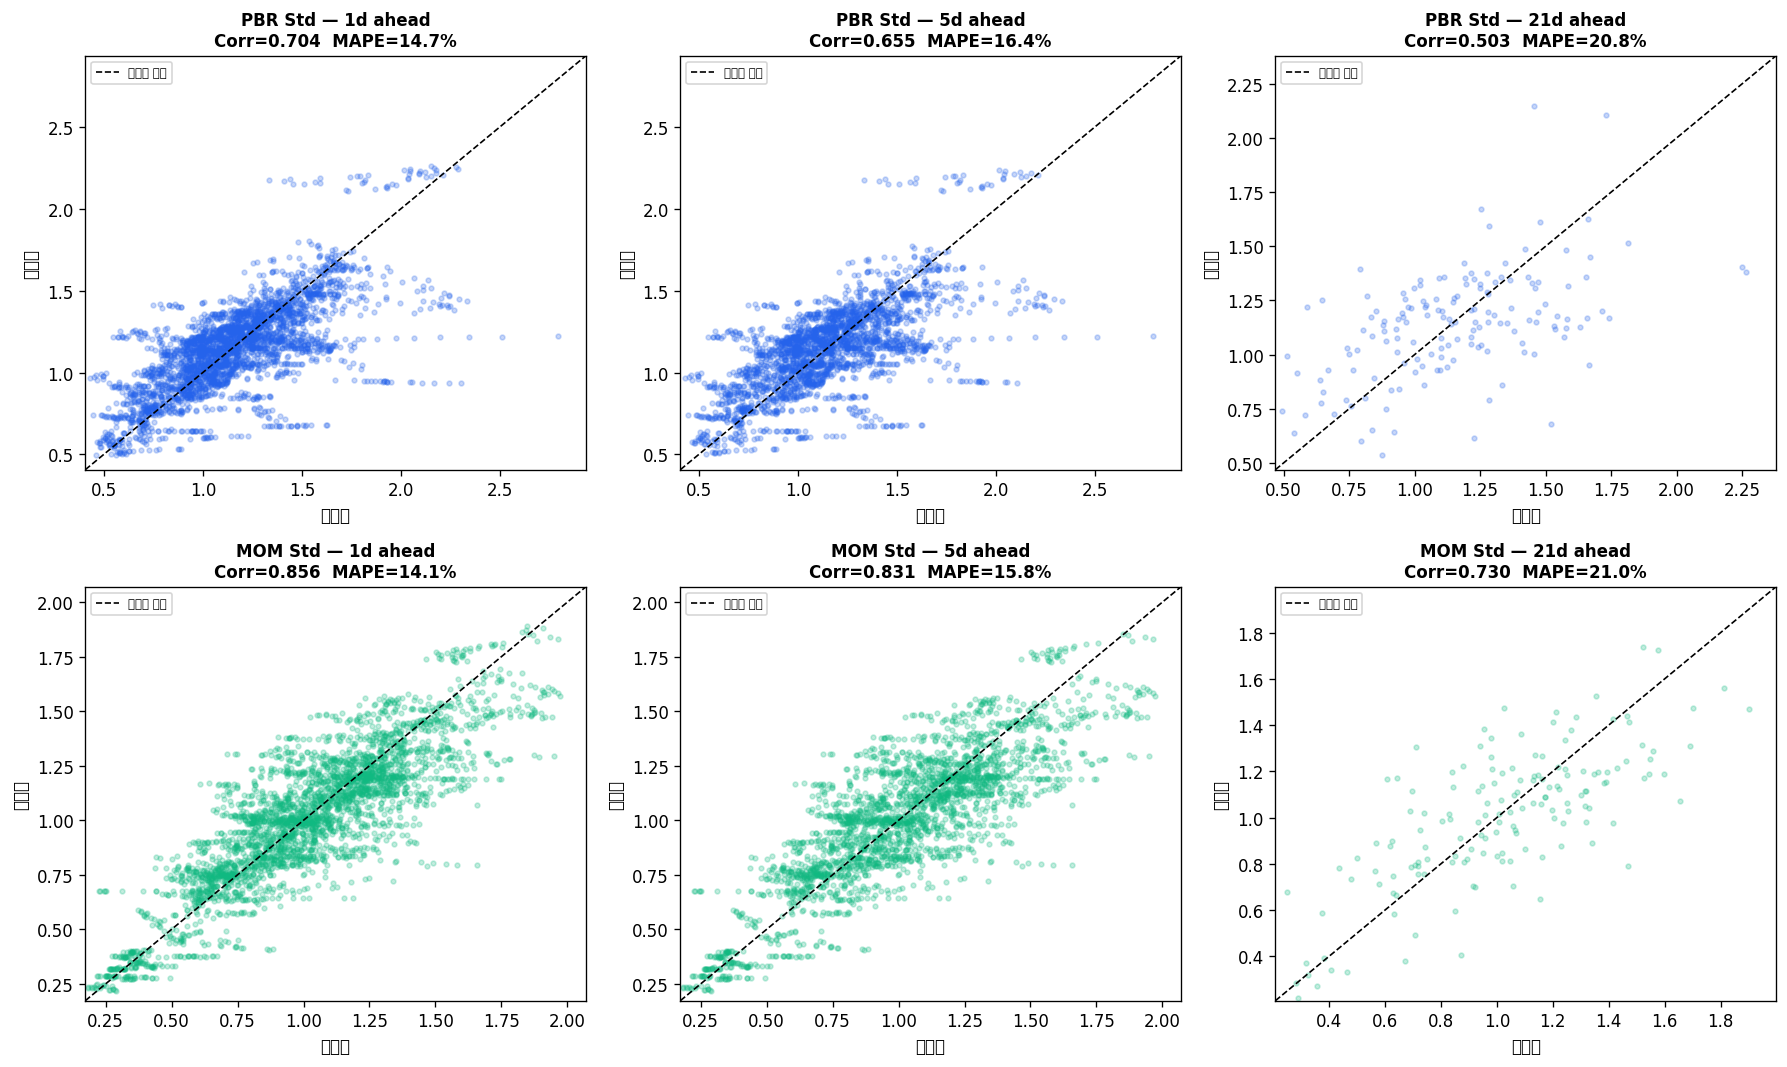

In [9]:
# ── Scatter: 예측 vs 실제 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, (name, res) in enumerate([("PBR", res_pbr), ("MOM", res_mom)]):
    for col, h in enumerate(HORIZONS):
        ax = axes[row][col]
        df = res[h].dropna()
        c  = colors[name]
        r  = eval_horizon(res[h], name, h)

        ax.scatter(df["actual"], df["pred_mean"], alpha=0.25, s=8, color=c)
        lo = min(df["actual"].min(), df["pred_mean"].min()) * 0.95
        hi = max(df["actual"].max(), df["pred_mean"].max()) * 1.05
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="완벽한 예측")
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_xlabel("실제값"); ax.set_ylabel("예측값")
        ax.set_title(f"{name} Std — {h_labels[h]}\nCorr={r['corr']:.3f}  MAPE={r['mape']:.1%}",
                     fontsize=10, fontweight="bold")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

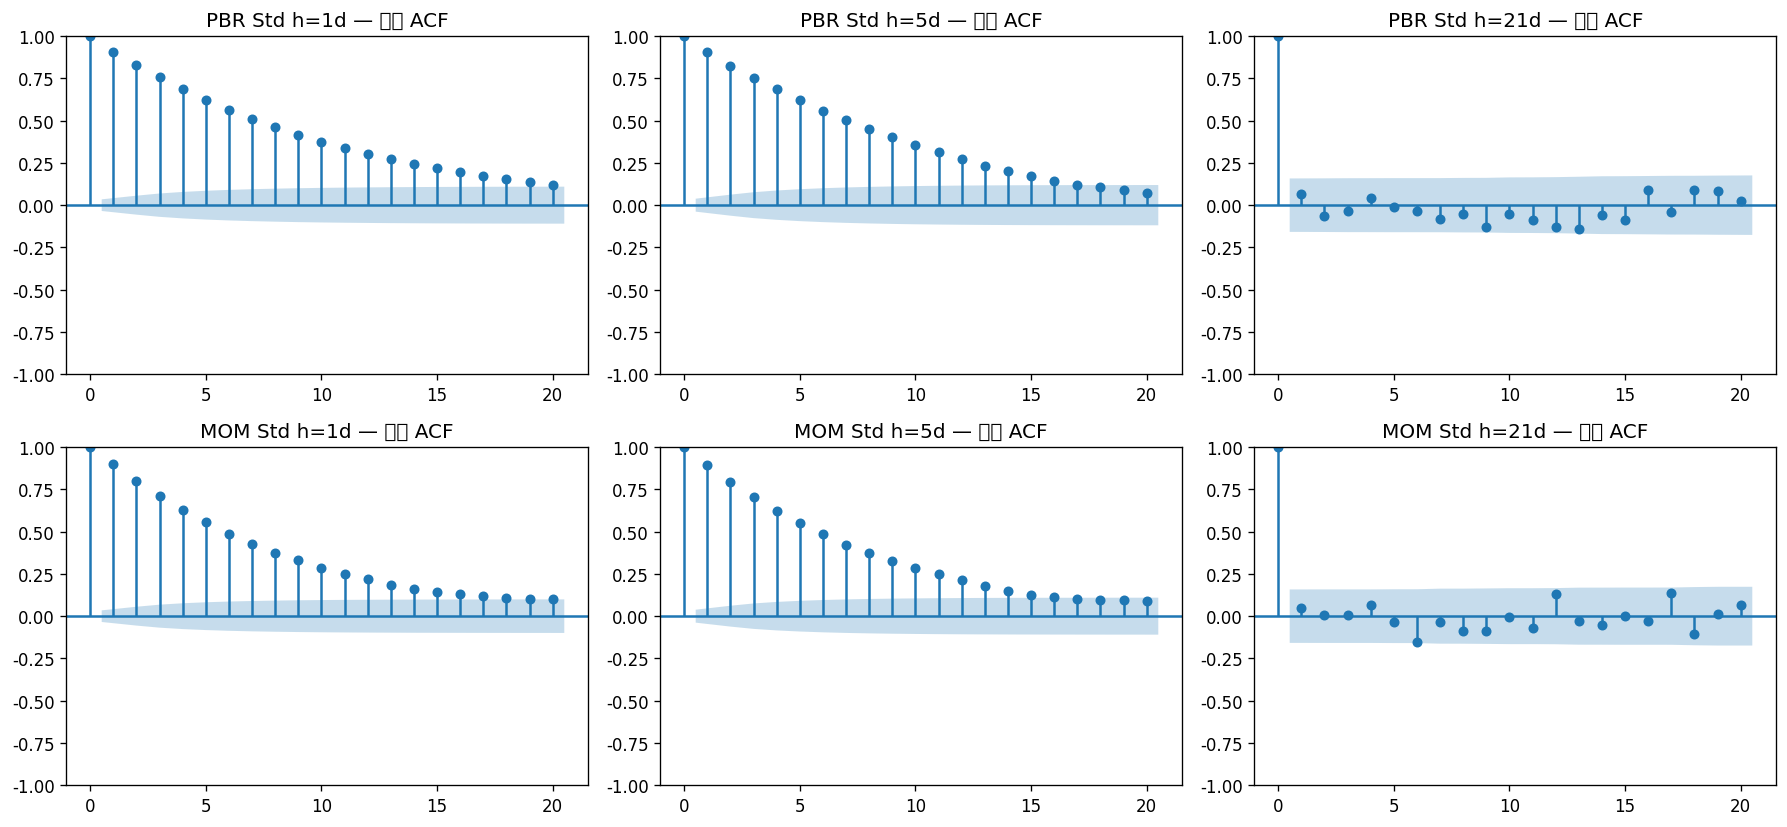

※ ACF가 신뢰구간 내 → GARCH가 구조를 잘 흡수 | 유의한 spike → 추가 모델 고려


In [10]:
# ── 잔차 ACF — 구조적 패턴 잔존 여부 ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for row, (name, res) in enumerate([("PBR", res_pbr), ("MOM", res_mom)]):
    for col, h in enumerate(HORIZONS):
        ax    = axes[row][col]
        resid = (res[h]["actual"] - res[h]["pred_mean"]).dropna()
        plot_acf(resid, lags=20, ax=ax, title=f"{name} Std h={h}d — 잔차 ACF")

plt.tight_layout()
plt.show()
print("※ ACF가 신뢰구간 내 → GARCH가 구조를 잘 흡수 | 유의한 spike → 추가 모델 고려")

## 결론 해석 가이드

| 지표 | 기대 패턴 | 의미 |
|------|-----------|------|
| RMSE/MAPE | h=1 < h=5 < h=21 | 멀수록 불확실성 증가 (자연스러움) |
| Corr | 높을수록 (>0.7) | 큰 추세 방향을 잘 따라감 |
| DirAcc | >55% | 랜덤워크 대비 방향 예측 우위 |
| 잔차 ACF | 신뢰구간 내 | GARCH가 자기상관 구조를 잘 흡수 |

### 실용적 활용
- **h=1d**: 다음 날 시장 스트레스 수준 조기 경보
- **h=5d**: 주간 섹터 분산도 변화 방향 예측 → 로테이션 전략 신호
- **h=21d**: 월간 변동성 레짐 파악 → 포지션 크기 조절 기준

### 한계 & 개선 방향
- GARCH 평균 방정식이 AR(1) → 실질 예측이 전날 값에 크게 의존
- 비대칭 충격 반영: `EGARCH` 또는 `GJR-GARCH`
- 두꺼운 꼬리: `dist='t'` (Student-t 분포)
- 외생 변수: KOSPI 수익률, VIX 등을 평균 방정식에 투입(ARX)

---
## z 기반 유의성 분류 — 방향 정확도 비교

> `delta = pred_21d - current_value`  
> `z = delta / pred_vol_21d`
>
> - **|z| > 1.65** : 모델이 유의한 변화라고 판단한 구간 → 방향을 잘 맞추는가?
> - **|z| ≤ 1.65** : 모델이 노이즈로 판단한 구간 → 방향 정확도가 낮은가?

In [11]:
# walk_forward_garch 재실행 — current 값 추가 저장
# (기존 res_pbr, res_mom에는 current가 없으므로 재계산)

TRAIN    = 252
TEST     = 21
HORIZONS = [1, 5, 21]

def walk_forward_garch_with_current(series: pd.Series, name: str) -> dict:
    s = series.dropna() * 100
    n = len(s)
    buf = {h: {"pred_mean": [], "pred_vol": [], "actual": [], "current": [], "date": []}
           for h in HORIZONS}

    n_windows = 0
    t = TRAIN
    while t < n:
        train = s.iloc[t - TRAIN: t]
        m   = arch_model(train, mean="ARX", lags=1, vol="GARCH", p=1, q=1, dist="normal")
        res = m.fit(disp="off", show_warning=False)
        fc  = res.forecast(horizon=max(HORIZONS), reindex=False)
        pred_means = fc.mean.iloc[-1].values
        pred_vars  = fc.variance.iloc[-1].values

        for k in range(TEST):
            if t + k >= n:
                break
            current_val = s.iloc[t + k]          # 예측 시점의 현재값
            for h in HORIZONS:
                step = k + h - 1
                tgt  = t + k + (h - 1)
                if step >= max(HORIZONS) or tgt >= n:
                    continue
                buf[h]["pred_mean"].append(pred_means[step] / 100)
                buf[h]["pred_vol"].append(np.sqrt(pred_vars[step]) / 100)
                buf[h]["actual"].append(s.iloc[tgt] / 100)
                buf[h]["current"].append(current_val / 100)   # ← 추가
                buf[h]["date"].append(s.index[t + k])

        n_windows += 1
        t += TEST
        if n_windows % 10 == 0:
            print(f"  [{name}] {n_windows}회 완료", end="\r")

    print(f"  [{name}] {n_windows}회 완료.    ")
    return {
        h: pd.DataFrame(buf[h]).set_index(pd.DatetimeIndex(buf[h]["date"])).drop(columns="date")
        for h in HORIZONS
    }

print("PBR 재실행 중...")
res_pbr = walk_forward_garch_with_current(pbr_std, "PBR")
print("MOM 재실행 중...")
res_mom = walk_forward_garch_with_current(mom_std, "MOM")
print("완료")


PBR 재실행 중...


  [PBR] 155회 완료.    
MOM 재실행 중...


  [MOM] 155회 완료.    
완료


In [12]:
# z 기반 분류 및 방향 정확도 분석
from scipy.stats import binomtest

def z_direction_analysis(res_h: pd.DataFrame, series_name: str, h: int, threshold: float = 1.65):
    df = res_h.dropna().copy()

    # delta = 예측값 - 현재값,  z = delta / 예측 변동성
    df["delta"]      = df["pred_mean"] - df["current"]
    df["z"]          = df["delta"]     / df["pred_vol"]

    # 실제 방향: 21일 후 실제값이 현재보다 올랐나 내렸나
    df["actual_dir"] = np.sign(df["actual"] - df["current"])
    # 예측 방향: 모델이 오를 것으로 봤나 내릴 것으로 봤나
    df["pred_dir"]   = np.sign(df["delta"])

    # |z| > threshold : 유의한 변화 구간
    sig_mask  = df["z"].abs() > threshold
    insig_mask = ~sig_mask

    results = {}
    for label, mask in [("유의 (|z|>1.65)", sig_mask), ("비유의 (|z|≤1.65)", insig_mask)]:
        sub   = df[mask & (df["actual_dir"] != 0) & (df["pred_dir"] != 0)]
        n_tot = len(sub)
        if n_tot == 0:
            print(f"  [{label}] 데이터 없음"); continue
        n_cor = (sub["actual_dir"] == sub["pred_dir"]).sum()
        acc   = n_cor / n_tot
        bt    = binomtest(n_cor, n_tot, p=0.5, alternative="greater")

        # 방향 분리: 예측이 상승이면 실제도 상승?
        up_mask   = sub["pred_dir"] > 0
        dn_mask   = sub["pred_dir"] < 0
        up_acc = (sub[up_mask]["actual_dir"] == 1).mean() if up_mask.sum() > 0 else float("nan")
        dn_acc = (sub[dn_mask]["actual_dir"] == -1).mean() if dn_mask.sum() > 0 else float("nan")

        results[label] = dict(n=n_tot, n_correct=n_cor, acc=acc, p=bt.pvalue,
                               up_n=up_mask.sum(), up_acc=up_acc,
                               dn_n=dn_mask.sum(), dn_acc=dn_acc)

    print(f"\n{'='*60}")
    print(f"  {series_name}  h={h}d   (threshold=|z|>{threshold})")
    print(f"{'='*60}")
    for label, r in results.items():
        sig_tag = "통계적 유의 ✓" if r["p"] < 0.05 else "유의하지 않음 ✗"
        print(f"  [{label}]")
        print(f"    전체 방향 정확도 : {r['acc']:.1%}  ({r['n_correct']}/{r['n']})  p={r['p']:.4f}  {sig_tag}")
        print(f"    예측 상승 정확도 : {r['up_acc']:.1%}  (n={r['up_n']})")
        print(f"    예측 하락 정확도 : {r['dn_acc']:.1%}  (n={r['dn_n']})")
    return results

print("\n[PBR Std — h=21d]")
r_pbr = z_direction_analysis(res_pbr[21], "PBR Std", 21)

print("\n[MOM Std — h=21d]")
r_mom = z_direction_analysis(res_mom[21], "MOM Std", 21)



[PBR Std — h=21d]

  PBR Std  h=21d   (threshold=|z|>1.65)
  [유의 (|z|>1.65)]
    전체 방향 정확도 : 83.3%  (5/6)  p=0.1094  유의하지 않음 ✗
    예측 상승 정확도 : 100.0%  (n=3)
    예측 하락 정확도 : 66.7%  (n=3)
  [비유의 (|z|≤1.65)]
    전체 방향 정확도 : 56.8%  (84/148)  p=0.0590  유의하지 않음 ✗
    예측 상승 정확도 : 53.3%  (n=75)
    예측 하락 정확도 : 60.3%  (n=73)

[MOM Std — h=21d]

  MOM Std  h=21d   (threshold=|z|>1.65)
  [유의 (|z|>1.65)]
    전체 방향 정확도 : 60.0%  (3/5)  p=0.5000  유의하지 않음 ✗
    예측 상승 정확도 : 75.0%  (n=4)
    예측 하락 정확도 : 0.0%  (n=1)
  [비유의 (|z|≤1.65)]
    전체 방향 정확도 : 60.4%  (90/149)  p=0.0069  통계적 유의 ✓
    예측 상승 정확도 : 68.4%  (n=57)
    예측 하락 정확도 : 55.4%  (n=92)


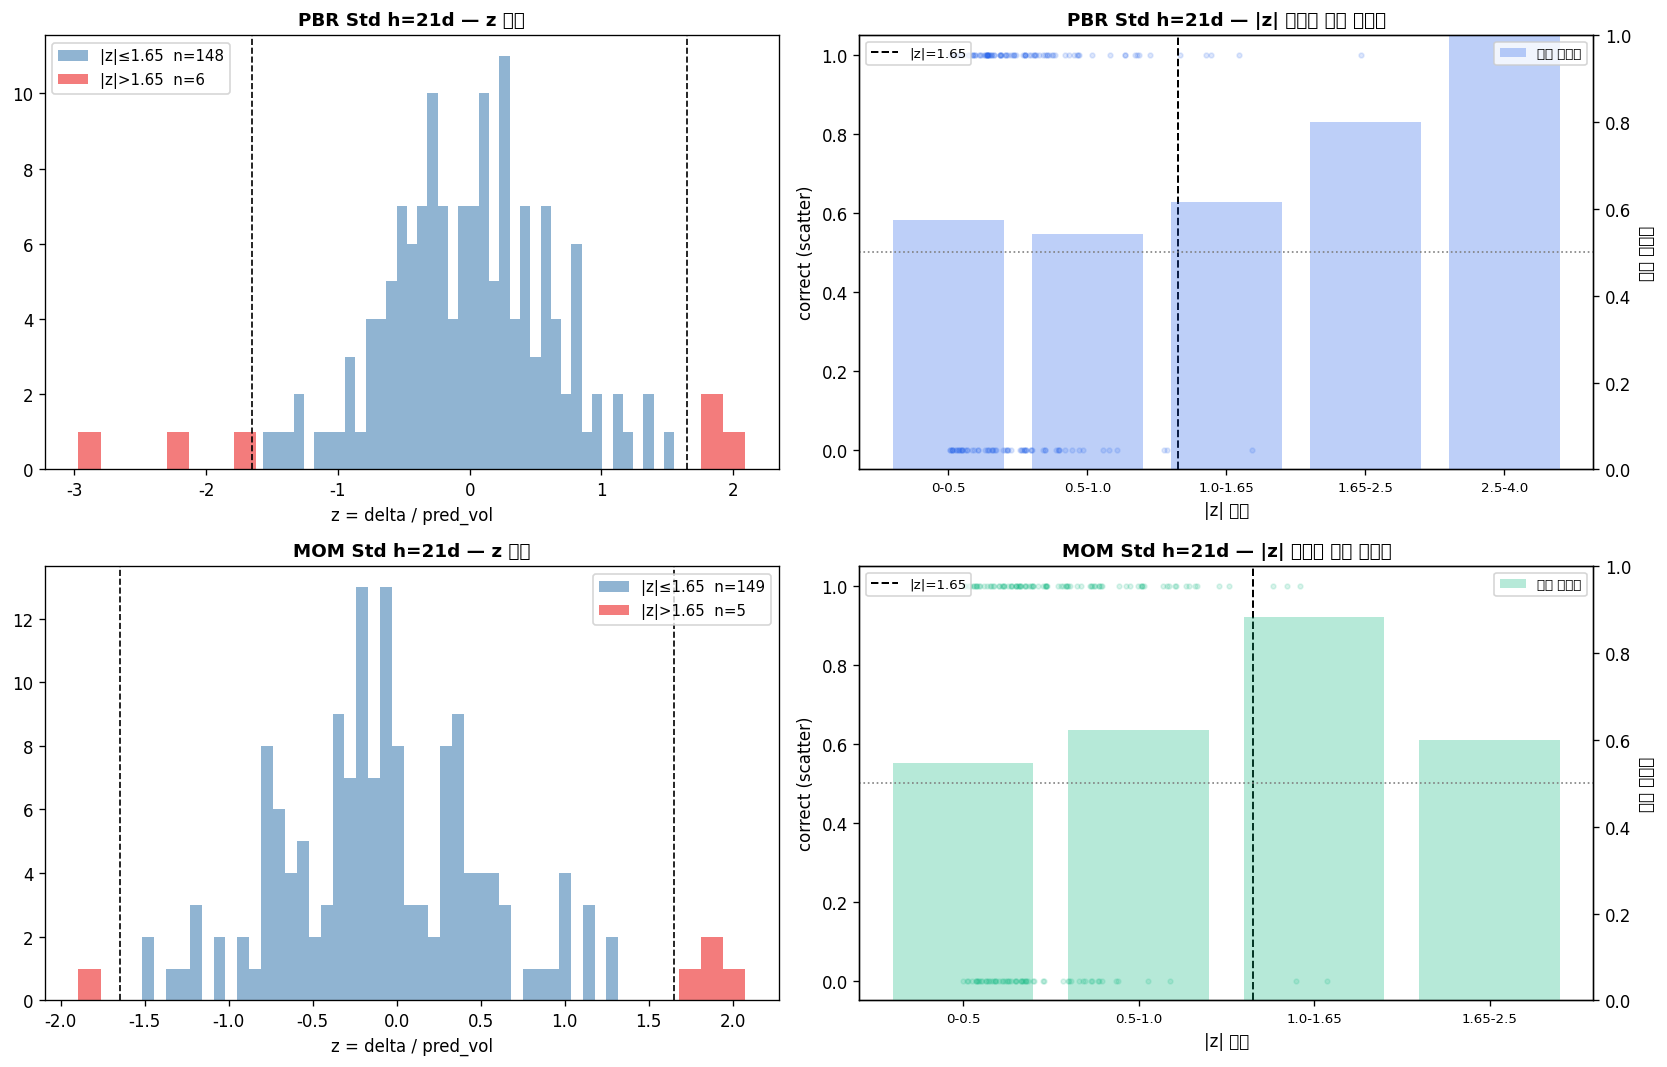

In [13]:
# 시각화 — z 분포 + 방향 정확도 대비
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, (name, res, color) in enumerate([("PBR", res_pbr, "#2563eb"), ("MOM", res_mom, "#10b981")]):
    df = res[21].dropna().copy()
    df["delta"] = df["pred_mean"] - df["current"]
    df["z"]     = df["delta"] / df["pred_vol"]
    df["actual_dir"] = np.sign(df["actual"] - df["current"])
    df["pred_dir"]   = np.sign(df["delta"])
    df["correct"]    = (df["actual_dir"] == df["pred_dir"]) & (df["actual_dir"] != 0) & (df["pred_dir"] != 0)

    # 좌: z 분포 히스토그램 — 유의/비유의 구분
    ax = axes[row][0]
    sig  = df[df["z"].abs() >  1.65]["z"]
    insig = df[df["z"].abs() <= 1.65]["z"]
    ax.hist(insig, bins=40, color="steelblue", alpha=0.6, label=f"|z|≤1.65  n={len(insig)}")
    ax.hist(sig,   bins=30, color="#ef4444",   alpha=0.7, label=f"|z|>1.65  n={len(sig)}")
    ax.axvline( 1.65, color="black", linestyle="--", linewidth=1)
    ax.axvline(-1.65, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{name} Std h=21d — z 분포", fontsize=11, fontweight="bold")
    ax.set_xlabel("z = delta / pred_vol")
    ax.legend(fontsize=9)

    # 우: |z| 구간별 방향 정확도 (rolling 시각화)
    ax2 = axes[row][1]
    df_sorted = df.sort_index()
    # |z| 기준으로 scatter: x=|z|, y=correct(1) or wrong(0)
    ax2.scatter(df_sorted["z"].abs(), df_sorted["correct"].astype(int),
                alpha=0.15, s=8, color=color)
    ax2.axvline(1.65, color="black", linestyle="--", linewidth=1.2, label="|z|=1.65")

    # 구간별 평균 정확도 bar
    max_z  = max(df_sorted["z"].abs().max() + 0.1, 4.1)
    bins   = [0, 0.5, 1.0, 1.65, 2.5, 4.0, max_z]
    labels = ["0-0.5","0.5-1.0","1.0-1.65","1.65-2.5","2.5-4.0",">4.0"]
    df_sorted["z_bin"] = pd.cut(df_sorted["z"].abs(), bins=bins, labels=labels)
    bin_acc = df_sorted.groupby("z_bin", observed=True)["correct"].agg(["mean","count"])
    ax2_r = ax2.twinx()
    valid_bins = bin_acc[bin_acc['count'] > 0]
    ax2_r.bar(range(len(valid_bins)), valid_bins["mean"], alpha=0.3, color=color, label="구간 정확도")
    ax2_r.set_ylim(0, 1)
    ax2_r.axhline(0.5, color="gray", linestyle=":", linewidth=1)
    ax2_r.set_ylabel("방향 정확도")
    valid_bins = bin_acc[bin_acc['count'] > 0]
    ax2.set_xticks(range(len(valid_bins)))
    ax2.set_xticklabels(valid_bins.index.tolist(), fontsize=8)
    ax2.set_xlabel("|z| 구간")
    ax2.set_ylabel("correct (scatter)")
    ax2.set_title(f"{name} Std h=21d — |z| 구간별 방향 정확도", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=8, loc="upper left")
    ax2_r.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()
